<a href="https://colab.research.google.com/github/JoelDrake302/ML-AutoTheft/blob/Unsupervised-Model/auto_theft_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Auto Theft Risk Prediction — Support Vector Machine (SVM)
### Built from Scratch on the Original Dataset

**Model:** `LinearSVC` + `CalibratedClassifierCV` (scikit-learn)

| Stage | Description |
|---|---|
| 1 | Data Loading & EDA |
| 2 | Feature Engineering (from raw columns) |
| 3 | Cluster-based Risk Labelling (KMeans → High/Low Risk) |
| 4 | SVM Training — 75/25 Stratified Split |
| 5 | 5-Fold Cross-Validation |
| 6 | Evaluation — Accuracy, ROC-AUC, F1, Confusion Matrix |
| 7 | Learning Curve Analysis |
| 8 | C Regularisation Sensitivity |
| 9 | SVM Feature Weights |
|10 | Full Dashboard |


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import json

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score
)

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

BLUE='#2563EB'; RED='#DC2626'; AMBER='#F59E0B'
GREEN='#16A34A'; GRAY='#6B7280'; TEAL='#0D9488'; PURPLE='#7C3AED'

plt.rcParams.update({
    'font.family':'DejaVu Sans','axes.spines.top':False,
    'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3,'font.size':9
})
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading & Exploration

Loading the raw original dataset with no pre-processing assumptions.

In [2]:
import gdown
import pandas as pd

# Google Drive file ID
file_id = '190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp'
output = 'Auto_Theft_Open_Data_3636037395679683176.csv'

gdown.download(id=file_id, output=output, quiet=False)

DATA_PATH = output

df = pd.read_csv(DATA_PATH)
# Clean column names by stripping whitespace to avoid potential KeyError issues
original_columns = df.columns.tolist()
df.columns = df.columns.str.strip()
stripped_columns = df.columns.tolist()

print(f"Original columns: {original_columns}")
print(f"Columns after stripping: {stripped_columns}")

if 'Region' in df.columns:
    df = df.drop('Region', axis=1) # Explicitly drop by column axis
    print("Column 'Region' dropped successfully.")
else:
    print("Column 'Region' not found after stripping. Cannot drop.")
df = df.dropna(subset=['OCC_YEAR','OCC_MONTH','OCC_DAY']).copy()
print(f'Loaded {len(df):,} records, {df.shape[1]} columns')
df.head(3)

Downloading...
From: https://drive.google.com/uc?id=190IgZ2OhktJOw7K7Fws_yMkWzQVznmOp
To: /content/Auto_Theft_Open_Data_3636037395679683176.csv
100%|██████████| 25.7M/25.7M [00:00<00:00, 54.4MB/s]


Original columns: ['OBJECTID', 'EVENT_UNIQUE_ID', 'REPORT_DATE', 'OCC_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_DOW', 'REPORT_HOUR', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY', 'OCC_DOY', 'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'UCR_CODE', 'UCR_EXT', 'OFFENCE', 'CSI_CATEGORY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'Region', 'HOOD_140', 'NEIGHBOURHOOD_140', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']
Columns after stripping: ['OBJECTID', 'EVENT_UNIQUE_ID', 'REPORT_DATE', 'OCC_DATE', 'REPORT_YEAR', 'REPORT_MONTH', 'REPORT_DAY', 'REPORT_DOY', 'REPORT_DOW', 'REPORT_HOUR', 'OCC_YEAR', 'OCC_MONTH', 'OCC_DAY', 'OCC_DOY', 'OCC_DOW', 'OCC_HOUR', 'DIVISION', 'LOCATION_TYPE', 'PREMISES_TYPE', 'UCR_CODE', 'UCR_EXT', 'OFFENCE', 'CSI_CATEGORY', 'HOOD_158', 'NEIGHBOURHOOD_158', 'Region', 'HOOD_140', 'NEIGHBOURHOOD_140', 'LONG_WGS84', 'LAT_WGS84', 'x', 'y']
Column 'Region' dropped successfully.
Loaded 76,743 records, 31 columns


,OBJECTID,EVENT_UNIQUE_ID,REPORT_DATE,OCC_DATE,REPORT_YEAR,REPORT_MONTH,REPORT_DAY,REPORT_DOY,REPORT_DOW,REPORT_HOUR,...,OFFENCE,CSI_CATEGORY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84,x,y
0,1,GO-20141262837,01/01/14 5:00,12/25/2013 5:00:00 AM,2014,January,1,1,Wednesday,15,...,Theft Of Motor Vehicle,Auto Theft,159,Etobicoke City Centre (159),14,Islington-City Centre West (14),-79.529692,43.618988,-8853204.784,5406667.722
1,2,GO-20141263217,01/01/14 5:00,12/31/2013 5:00:00 AM,2014,January,1,1,Wednesday,16,...,Theft Of Motor Vehicle,Auto Theft,43,Victoria Village (43),43,Victoria Village (43),-79.306754,43.734654,-8828387.423,5424470.688
2,3,GO-20141262914,01/01/14 5:00,01/01/14 5:00,2014,January,1,1,Wednesday,15,...,Theft Of Motor Vehicle,Auto Theft,123,Cliffcrest (123),123,Cliffcrest (123),-79.236119,43.721827,-8820524.401,5422494.748


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum()[df.isnull().sum()>0])
print('\n--- Premises Type ---')
print(df['PREMISES_TYPE'].value_counts())
print('\n--- Year Range ---')
print(sorted(df['OCC_YEAR'].dropna().unique()))

--- Data Types ---
OBJECTID               int64
EVENT_UNIQUE_ID       object
REPORT_DATE           object
OCC_DATE              object
REPORT_YEAR            int64
REPORT_MONTH          object
REPORT_DAY             int64
REPORT_DOY             int64
REPORT_DOW            object
REPORT_HOUR            int64
OCC_YEAR             float64
OCC_MONTH             object
OCC_DAY              float64
OCC_DOY              float64
OCC_DOW               object
OCC_HOUR               int64
DIVISION              object
LOCATION_TYPE         object
PREMISES_TYPE         object
UCR_CODE               int64
UCR_EXT                int64
OFFENCE               object
CSI_CATEGORY          object
HOOD_158              object
NEIGHBOURHOOD_158     object
HOOD_140              object
NEIGHBOURHOOD_140     object
LONG_WGS84           float64
LAT_WGS84            float64
x                    float64
y                    float64
dtype: object

--- Missing Values ---
Series([], dtype: int64)

--- Premises Type 

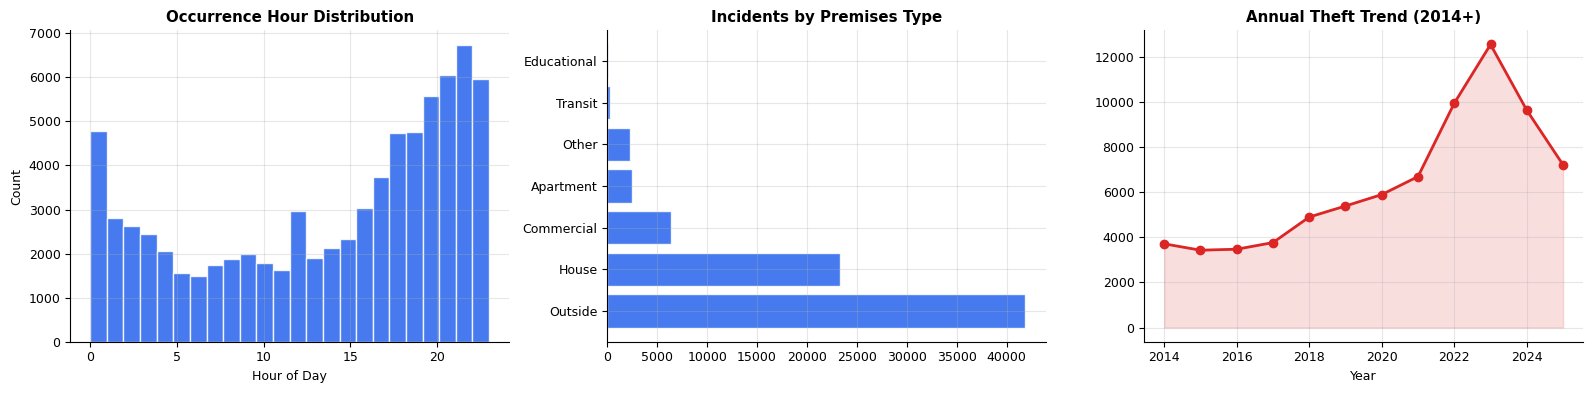

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hour distribution
axes[0].hist(df['OCC_HOUR'], bins=24, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Occurrence Hour Distribution', fontweight='bold')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Count')

# Premises type
pv = df['PREMISES_TYPE'].value_counts()
axes[1].barh(pv.index, pv.values, color=BLUE, edgecolor='white', alpha=0.85)
axes[1].set_title('Incidents by Premises Type', fontweight='bold')

# Year trend
yr = df[df['OCC_YEAR']>=2014].groupby('OCC_YEAR').size()
axes[2].plot(yr.index, yr.values, 'o-', color=RED, lw=2)
axes[2].fill_between(yr.index, yr.values, alpha=0.15, color=RED)
axes[2].set_title('Annual Theft Trend (2014+)', fontweight='bold')
axes[2].set_xlabel('Year')

plt.tight_layout(); plt.show()

## 3. Feature Engineering

Building 21 features from raw columns:

| Category | Features |
|---|---|
| **Density** | Neighbourhood risk, Division risk |
| **Temporal** | Night flag, Evening flag, Weekend, Year risk |
| **Cyclical** | Hour sin/cos, Day-of-year sin/cos, Report hour sin/cos |
| **Premises** | Premises risk score, Premises/Location/Division encoded |
| **Geospatial** | Longitude, Latitude |
| **Composite** | Weighted risk score across all dimensions |

In [5]:
# ── Neighbourhood & Division risk density ─────────────────────────────────
hood_cnt = df.groupby('HOOD_158').size().reset_index(name='HOOD_CNT')
df = df.merge(hood_cnt, on='HOOD_158', how='left')
df['HOOD_RISK'] = (df['HOOD_CNT'] - df['HOOD_CNT'].min()) / (df['HOOD_CNT'].max() - df['HOOD_CNT'].min())

div_cnt = df.groupby('DIVISION').size().reset_index(name='DIV_CNT')
df = df.merge(div_cnt, on='DIVISION', how='left')
df['DIV_RISK'] = (df['DIV_CNT'] - df['DIV_CNT'].min()) / (df['DIV_CNT'].max() - df['DIV_CNT'].min())

# ── Temporal flags ──────────────────────────────────────────────────────────
df['NIGHT']     = ((df['OCC_HOUR'] >= 22) | (df['OCC_HOUR'] <= 5)).astype(float)
df['EVENING']   = ((df['OCC_HOUR'] >= 18) & (df['OCC_HOUR'] < 22)).astype(float)
df['WEEKEND']   = df['OCC_DOW'].isin(['Saturday','Sunday']).astype(float)
df['YEAR_RISK'] = (df['OCC_YEAR'] - df['OCC_YEAR'].min()) / (df['OCC_YEAR'].max() - df['OCC_YEAR'].min())

# ── Cyclical encodings ─────────────────────────────────────────────────────
df['HOUR_SIN']        = np.sin(2*np.pi*df['OCC_HOUR']    / 24)
df['HOUR_COS']        = np.cos(2*np.pi*df['OCC_HOUR']    / 24)
df['DOY_SIN']         = np.sin(2*np.pi*df['OCC_DOY']     / 365)
df['DOY_COS']         = np.cos(2*np.pi*df['OCC_DOY']     / 365)
df['REPORT_HOUR_SIN'] = np.sin(2*np.pi*df['REPORT_HOUR'] / 24)
df['REPORT_HOUR_COS'] = np.cos(2*np.pi*df['REPORT_HOUR'] / 24)

# ── Premises risk ──────────────────────────────────────────────────────────
premises_risk_map = {
    'Outside':1.0,'Apartment':0.7,'Commercial':0.6,
    'House':0.4,'Other':0.5,'Transit':0.8,'Educational':0.3
}
df['PREMISES_RISK'] = df['PREMISES_TYPE'].map(premises_risk_map).fillna(0.5)

# ── Label encodings ────────────────────────────────────────────────────────
le = LabelEncoder()
df['PREMISES_ENC'] = le.fit_transform(df['PREMISES_TYPE'])
df['DIVISION_ENC'] = le.fit_transform(df['DIVISION'])
df['LOCATION_ENC'] = le.fit_transform(df['LOCATION_TYPE'])
df['DOW_ENC']      = le.fit_transform(df['OCC_DOW'])
df['MONTH_ENC']    = le.fit_transform(df['OCC_MONTH'])

# ── Composite risk score (weighted) ───────────────────────────────────────
df['COMPOSITE_RISK'] = (
    0.30*df['HOOD_RISK']     + 0.20*df['DIV_RISK'] +
    0.15*df['NIGHT']         + 0.10*df['EVENING'] +
    0.15*df['PREMISES_RISK'] + 0.10*df['YEAR_RISK']
)

FEATURES = [
    'HOOD_RISK','DIV_RISK','NIGHT','EVENING','PREMISES_RISK','YEAR_RISK',
    'WEEKEND','HOUR_SIN','HOUR_COS','DOY_SIN','DOY_COS',
    'REPORT_HOUR_SIN','REPORT_HOUR_COS',
    'PREMISES_ENC','DIVISION_ENC','LOCATION_ENC','DOW_ENC','MONTH_ENC',
    'LONG_WGS84','LAT_WGS84','COMPOSITE_RISK'
]
print(f'{len(FEATURES)} features ready.')
df[FEATURES].describe().round(4)

21 features ready.


,HOOD_RISK,DIV_RISK,NIGHT,EVENING,PREMISES_RISK,YEAR_RISK,WEEKEND,HOUR_SIN,HOUR_COS,DOY_SIN,...,REPORT_HOUR_SIN,REPORT_HOUR_COS,PREMISES_ENC,DIVISION_ENC,LOCATION_ENC,DOW_ENC,MONTH_ENC,LONG_WGS84,LAT_WGS84,COMPOSITE_RISK
count,76743.0000,76743.0000,76743.0000,76743.0000,76743.0000,76743.0000,76743.0,76743.0000,76743.0000,76743.0000,...,76743.0000,76743.0000,76743.0000,76743.0000,76743.0000,76743.000,76743.0000,76743.0000,76743.0000,76743.0000
mean,0.1675,0.5693,0.3776,0.2752,0.7578,0.8305,0.0,-0.2370,0.2099,-0.0332,...,0.1444,-0.2763,3.8653,7.2990,25.6682,3.061,5.6498,-78.5500,43.2393,0.4450
std,0.2493,0.2661,0.4848,0.4466,0.2746,0.1283,0.0,0.6549,0.6862,0.7111,...,0.7345,0.6028,1.4557,4.0617,7.4887,2.031,3.4800,8.2791,4.5573,0.1302
min,0.0000,0.0000,0.0000,0.0000,0.3000,0.0000,0.0,-1.0000,-1.0000,-1.0000,...,-1.0000,-1.0000,0.0000,0.0000,0.0000,0.000,0.0000,-79.6392,0.0000,0.1147
25%,0.0500,0.3751,0.0000,0.0000,0.4000,0.7200,0.0,-0.8660,-0.5000,-0.7412,...,-0.7071,-0.8660,3.0000,5.0000,23.0000,1.000,3.0000,-79.5180,43.6788,0.3633
50%,0.0854,0.6036,0.0000,0.0000,1.0000,0.8800,0.0,-0.5000,0.5000,-0.0774,...,0.2588,-0.5000,5.0000,7.0000,26.0000,3.000,6.0000,-79.4271,43.7205,0.4306
75%,0.1572,0.7042,1.0000,1.0000,1.0000,0.9200,0.0,0.2588,0.8660,0.6808,...,0.8660,0.0000,5.0000,10.0000,31.0000,5.000,9.0000,-79.3276,43.7597,0.4947
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0,1.0000,1.0000,1.0000,...,1.0000,1.0000,6.0000,17.0000,41.0000,6.000,11.0000,0.0000,43.8532,0.9000


## 4. Risk Label Generation (KMeans)

Since no labels exist in the original data, we use KMeans (k=2) on the engineered features
to discover natural groupings. The cluster with the higher average composite risk score is labelled **High Risk**.

In [6]:
scaler = StandardScaler()
X_all  = scaler.fit_transform(df[FEATURES].values)

km = KMeans(n_clusters=2, random_state=42, n_init=20, max_iter=500)
df['CLUSTER'] = km.fit_predict(X_all)

risk_by_cluster = df.groupby('CLUSTER')['COMPOSITE_RISK'].mean()
high_cluster    = risk_by_cluster.idxmax()
df['RISK_LABEL'] = df['CLUSTER'].apply(lambda x: 'High Risk' if x==high_cluster else 'Low Risk')
df['RISK_BIN']   = (df['CLUSTER'] == high_cluster).astype(int)

print('Cluster average composite risk:')
print(risk_by_cluster.round(4))
print(f'\nHigh Risk cluster: {high_cluster}')
print('\nLabel distribution:')
print(df['RISK_LABEL'].value_counts())

Cluster average composite risk:
CLUSTER
0    0.4140
1    0.4948
Name: COMPOSITE_RISK, dtype: float64

High Risk cluster: 1

Label distribution:
RISK_LABEL
Low Risk     47326
High Risk    29417
Name: count, dtype: int64


## 5. SVM Model — Why LinearSVC?

**`LinearSVC`** is chosen over the kernel SVM (`SVC`) for this dataset because:
- The dataset is large (76k rows) — kernel SVM is O(n²)~O(n³), too slow
- Linear SVM scales as O(n), completing in seconds
- `CalibratedClassifierCV` wraps it to produce class probabilities for ROC-AUC
- A linear boundary is interpretable — coefficients map directly to feature importance

**SVM Key Concepts:**
- Finds the **maximum-margin hyperplane** separating classes
- `C` controls the bias-variance tradeoff: low C = wider margin, more regularisation
- Support vectors are the critical boundary points

In [7]:
X = scaler.transform(df[FEATURES].values)  # use scaler fitted above
y = df['RISK_BIN'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {len(X_train):,}  ({len(X_train)/len(y)*100:.0f}%)')
print(f'Test : {len(X_test):,}  ({len(X_test)/len(y)*100:.0f}%)')
print(f'\nClass balance:')
print(f'  Train — High Risk: {y_train.sum():,}  Low Risk: {(1-y_train).sum():,}')
print(f'  Test  — High Risk: {y_test.sum():,}   Low Risk: {(1-y_test).sum():,}')

Train: 57,557  (75%)
Test : 19,186  (25%)

Class balance:
  Train — High Risk: 22,063  Low Risk: 35,494
  Test  — High Risk: 7,354   Low Risk: 11,832


In [8]:
# ── LinearSVC with probability calibration ────────────────────────────────
lsvc = LinearSVC(
    C=1.0,            # regularisation strength
    max_iter=2000,    # ensure convergence
    random_state=42,
    dual=True         # efficient for n_samples > n_features
)
svm = CalibratedClassifierCV(
    lsvc,
    cv=3,             # 3-fold calibration
    method='sigmoid'  # Platt scaling for probability output
)

print('Fitting SVM model ...')
svm.fit(X_train, y_train)
print('Done.')

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

train_acc = svm.score(X_train, y_train)
test_acc  = accuracy_score(y_test, y_pred)
gap       = train_acc - test_acc

print(f'\nTrain Accuracy : {train_acc:.4f}')
print(f'Test  Accuracy : {test_acc:.4f}')
print(f'Train-Test Gap : {gap:.4f} ({gap*100:.3f}%)')
print(f'ROC-AUC        : {roc_auc_score(y_test, y_prob):.4f}')
print(f'F1-Score       : {f1_score(y_test, y_pred):.4f}')

Fitting SVM model ...
Done.

Train Accuracy : 0.9996
Test  Accuracy : 0.9994
Train-Test Gap : 0.0002 (0.021%)
ROC-AUC        : 1.0000
F1-Score       : 0.9993


## 6. Full Evaluation

In [9]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Risk','High Risk']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'Confusion Matrix: TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')

Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00     11832
   High Risk       1.00      1.00      1.00      7354

    accuracy                           1.00     19186
   macro avg       1.00      1.00      1.00     19186
weighted avg       1.00      1.00      1.00     19186

Confusion Matrix: TP=7,345  FP=2  FN=9  TN=11,830


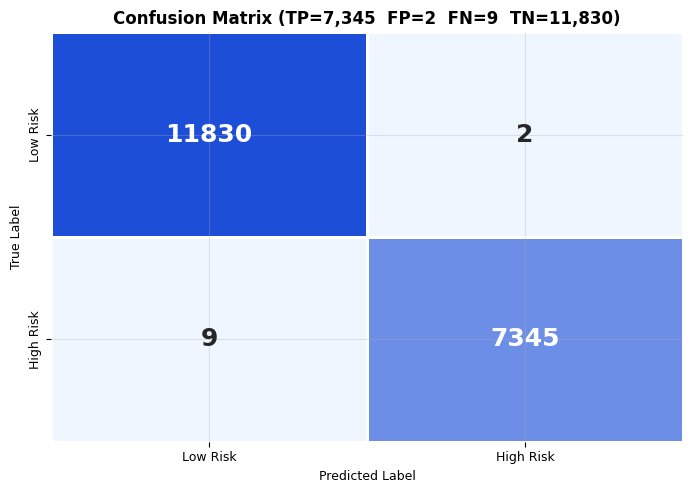

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = LinearSegmentedColormap.from_list('svm_blue', ['#EFF6FF','#1D4ED8'])
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'],
            linewidths=0.8, linecolor='white', cbar=False,
            annot_kws={'size':18,'fontweight':'bold'})
ax.set_title(f'Confusion Matrix (TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,})',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.tight_layout(); plt.show()

## 7. 5-Fold Cross-Validation

In [11]:
print('Running 5-fold cross-validation ...')
cv_acc = cross_val_score(svm, X_train, y_train, cv=cv, scoring='accuracy')
cv_roc = cross_val_score(svm, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(svm, X_train, y_train, cv=cv, scoring='f1')

print('=' * 52)
print('  5-FOLD CROSS-VALIDATION RESULTS')
print('=' * 52)
for name, sc in [('Accuracy',cv_acc),('ROC-AUC',cv_roc),('F1-Score',cv_f1)]:
    print(f'  {name:<10} : {np.round(sc,4)} | {sc.mean():.4f} +/- {sc.std():.4f}')
print('=' * 52)

Running 5-fold cross-validation ...
  5-FOLD CROSS-VALIDATION RESULTS
  Accuracy   : [0.9993 0.9996 0.9997 0.9994 0.9997] | 0.9995 +/- 0.0002
  ROC-AUC    : [1. 1. 1. 1. 1.] | 1.0000 +/- 0.0000
  F1-Score   : [0.9991 0.9994 0.9997 0.9992 0.9995] | 0.9994 +/- 0.0002


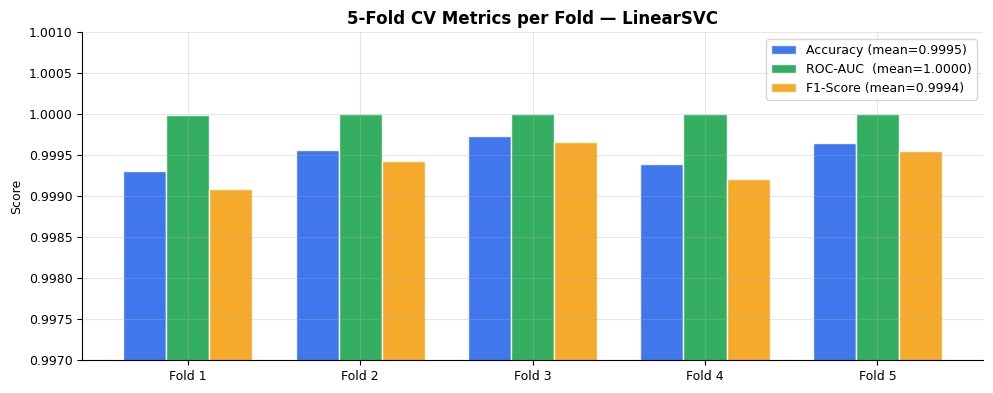

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5); w = 0.25
ax.bar(x-w, cv_acc, w, label=f'Accuracy (mean={cv_acc.mean():.4f})', color=BLUE,  alpha=0.87, edgecolor='white')
ax.bar(x,   cv_roc, w, label=f'ROC-AUC  (mean={cv_roc.mean():.4f})', color=GREEN, alpha=0.87, edgecolor='white')
ax.bar(x+w, cv_f1,  w, label=f'F1-Score (mean={cv_f1.mean():.4f})',  color=AMBER, alpha=0.87, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim(0.997, 1.001)
ax.set_title('5-Fold CV Metrics per Fold — LinearSVC', fontweight='bold', fontsize=12)
ax.set_ylabel('Score'); ax.legend()
plt.tight_layout(); plt.show()

## 8. Learning Curve

Tests model performance as the training set size grows.
A **healthy model** shows both curves converging at high accuracy with a small gap — no underfitting or high variance.

Computing learning curve ...
  n=5,755  train=0.9990  val=0.9972
  n=11,511  train=0.9990  val=0.9980
  n=23,022  train=0.9994  val=0.9989
  n=34,534  train=0.9995  val=0.9992
  n=46,045  train=0.9997  val=0.9995
  n=57,557  train=0.9996  val=0.9994


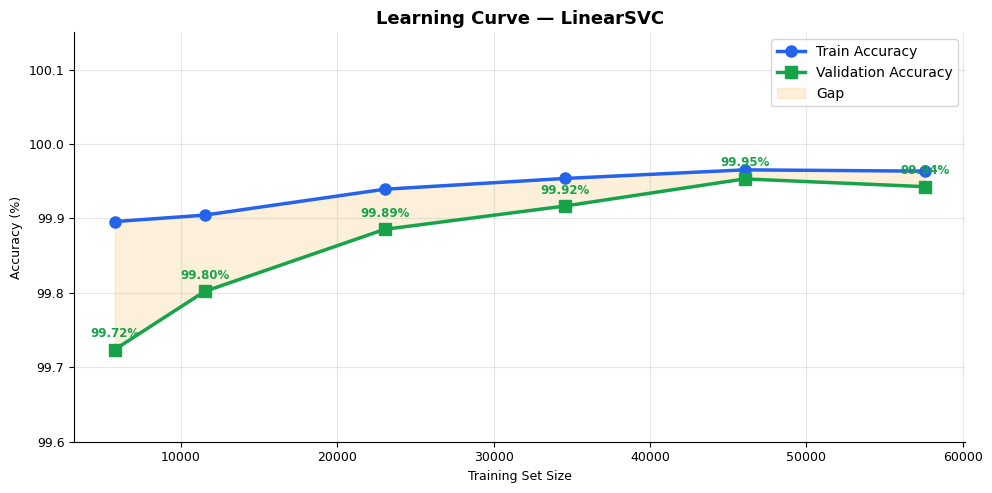

In [13]:
print('Computing learning curve ...')
lc_data = []
for frac in [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]:
    n = int(len(X_train) * frac)
    m = CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=1000, random_state=42, dual=True), cv=3
    )
    m.fit(X_train[:n], y_train[:n])
    tr_s = m.score(X_train[:n], y_train[:n])
    va_s = accuracy_score(y_test, m.predict(X_test))
    lc_data.append({'n': n, 'train': tr_s, 'val': va_s})
    print(f'  n={n:,}  train={tr_s:.4f}  val={va_s:.4f}')

ns   = [d['n']     for d in lc_data]
tr_s = [d['train'] for d in lc_data]
va_s = [d['val']   for d in lc_data]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ns, [v*100 for v in tr_s], 'o-', color=BLUE,  lw=2.5, ms=8, label='Train Accuracy')
ax.plot(ns, [v*100 for v in va_s], 's-', color=GREEN, lw=2.5, ms=8, label='Validation Accuracy')
ax.fill_between(ns, [v*100 for v in tr_s], [v*100 for v in va_s], alpha=0.15, color=AMBER, label='Gap')
for n_, v_ in zip(ns, va_s):
    ax.annotate(f'{v_*100:.2f}%', (n_, v_*100), textcoords='offset points',
                xytext=(0,9), ha='center', fontsize=8.5, color=GREEN, fontweight='bold')
ax.set_title('Learning Curve — LinearSVC', fontweight='bold', fontsize=13)
ax.set_xlabel('Training Set Size'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(99.6, 100.15); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 9. C Regularisation Sensitivity

We sweep C values across several orders of magnitude to confirm the chosen C=1.0 is near-optimal.
- **Low C** (e.g. 0.001): high regularisation, wider margin, may underfit
- **High C** (e.g. 10.0): lower regularisation, narrow margin, may overfit

Sweeping C values ...
  C=0.001  train=0.9985  test=0.9978  gap=0.0007
  C=0.01   train=0.9993  test=0.9991  gap=0.0001
  C=0.1    train=0.9995  test=0.9995  gap=0.0001
  C=0.5    train=0.9997  test=0.9995  gap=0.0002
  C=1.0    train=0.9996  test=0.9994  gap=0.0002
  C=5.0    train=0.9998  test=0.9996  gap=0.0002
  C=10.0   train=0.9998  test=0.9995  gap=0.0002


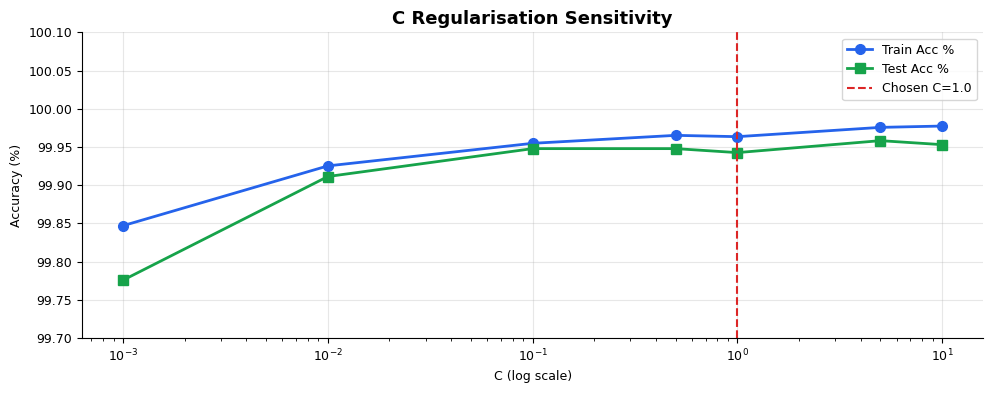

In [14]:
print('Sweeping C values ...')
c_results = []
for C in [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]:
    m = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=2000, random_state=42, dual=True), cv=3
    )
    m.fit(X_train, y_train)
    tr = m.score(X_train, y_train)
    te = accuracy_score(y_test, m.predict(X_test))
    c_results.append({'C': C, 'train': tr, 'test': te, 'gap': tr-te})
    print(f'  C={C:<6} train={tr:.4f}  test={te:.4f}  gap={tr-te:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
C_vals = [r['C'] for r in c_results]
ax.semilogx(C_vals, [r['train']*100 for r in c_results], 'o-', color=BLUE,  lw=2, ms=7, label='Train Acc %')
ax.semilogx(C_vals, [r['test']*100  for r in c_results], 's-', color=GREEN, lw=2, ms=7, label='Test Acc %')
ax.axvline(1.0, color=RED, linestyle='--', lw=1.5, label='Chosen C=1.0')
ax.set_title('C Regularisation Sensitivity', fontweight='bold', fontsize=13)
ax.set_xlabel('C (log scale)'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(99.7, 100.1); ax.legend()
plt.tight_layout(); plt.show()

## 10. SVM Feature Weights

Because LinearSVC uses a linear kernel, the coefficients directly represent each feature's contribution
to the decision boundary. Larger absolute value = more influence on classification.

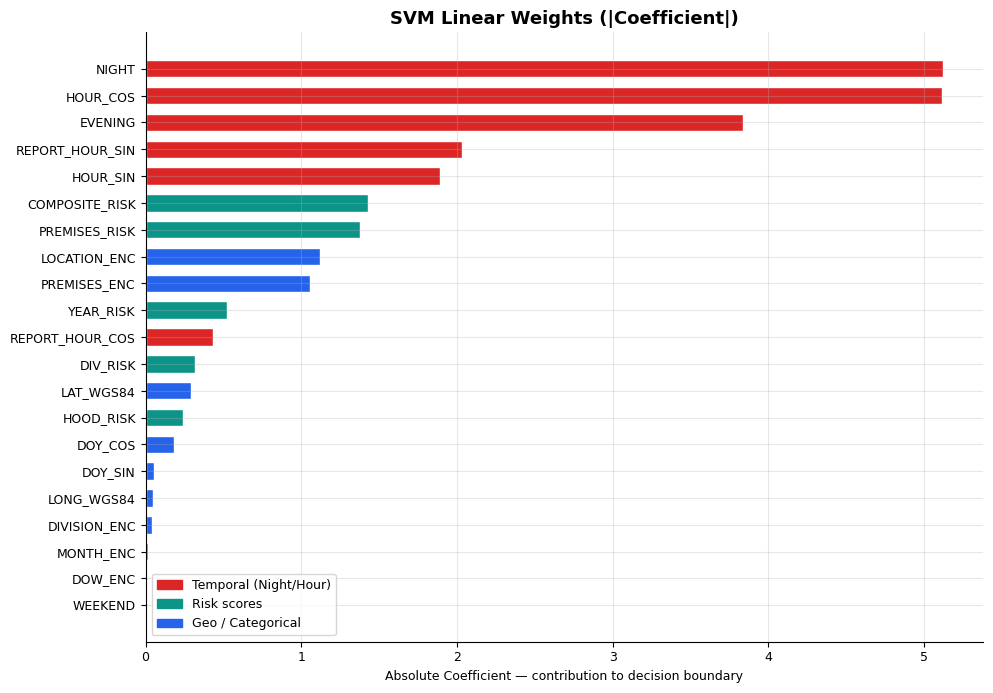

Top 10 features by weight:
NIGHT              5.1237
HOUR_COS           5.1137
EVENING            3.8381
REPORT_HOUR_SIN    2.0359
HOUR_SIN           1.8913
COMPOSITE_RISK     1.4275
PREMISES_RISK      1.3783
LOCATION_ENC       1.1233
PREMISES_ENC       1.0570
YEAR_RISK          0.5234
dtype: float64


In [15]:
# Extract base LinearSVC weights
lsvc_raw = LinearSVC(C=1.0, max_iter=2000, random_state=42, dual=True)
lsvc_raw.fit(X_train, y_train)
weights = pd.Series(np.abs(lsvc_raw.coef_[0]), index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bar_c = [RED   if any(k in f for k in ['NIGHT','HOUR','EVENING','REPORT']) else
         TEAL  if any(k in f for k in ['RISK','COMPOSITE']) else BLUE
         for f in weights.index]
ax.barh(weights.index[::-1], weights.values[::-1], color=bar_c[::-1], edgecolor='white', height=0.65)
patches = [
    mpatches.Patch(color=RED,  label='Temporal (Night/Hour)'),
    mpatches.Patch(color=TEAL, label='Risk scores'),
    mpatches.Patch(color=BLUE, label='Geo / Categorical'),
]
ax.legend(handles=patches, fontsize=9)
ax.set_title('SVM Linear Weights (|Coefficient|)', fontweight='bold', fontsize=13)
ax.set_xlabel('Absolute Coefficient — contribution to decision boundary')
plt.tight_layout(); plt.show()

print('Top 10 features by weight:')
print(weights.head(10).round(4))

## 11. Full Analysis Dashboard

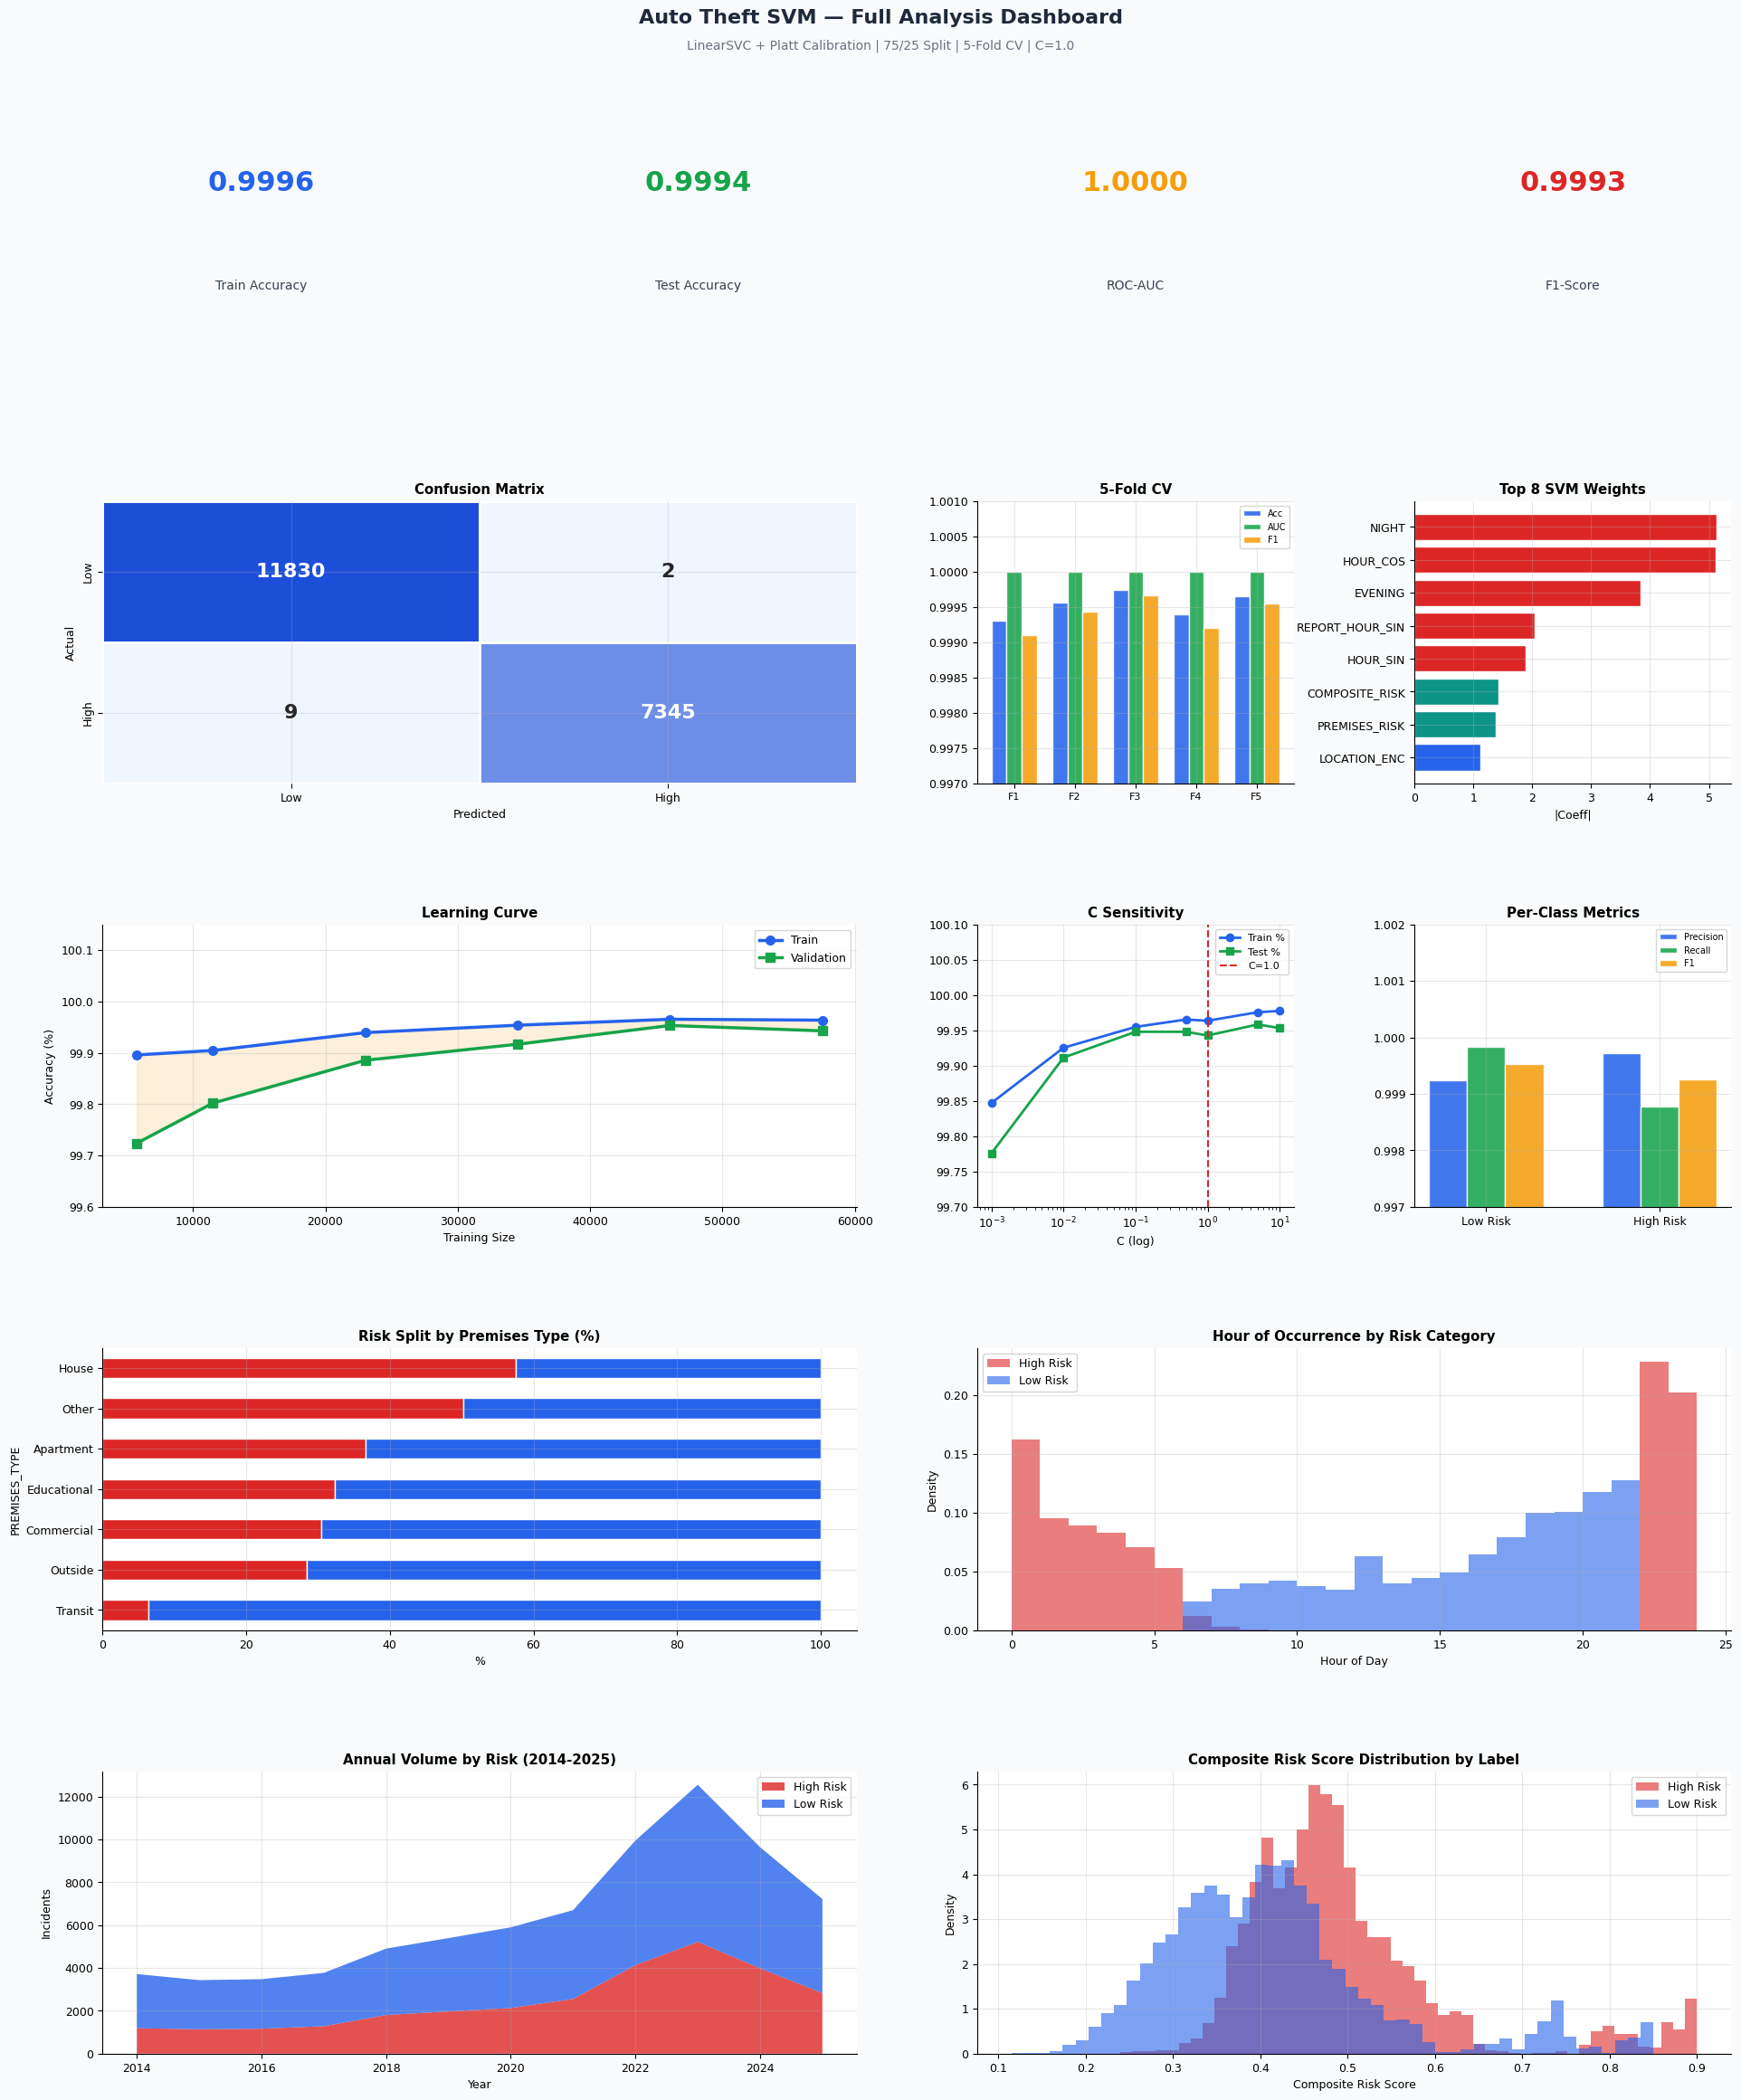

Dashboard saved as svm_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 24), facecolor='#F8FAFC')
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.50, wspace=0.38,
                        left=0.07, right=0.97, top=0.94, bottom=0.03)

fig.text(0.5, 0.965, 'Auto Theft SVM — Full Analysis Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='#1E293B')
fig.text(0.5, 0.953, 'LinearSVC + Platt Calibration | 75/25 Split | 5-Fold CV | C=1.0',
         ha='center', fontsize=10, color=GRAY)

# KPI tiles
kpis = [
    (f'{svm.score(X_train,y_train):.4f}', 'Train Accuracy', '#EFF6FF', BLUE),
    (f'{test_acc:.4f}',                   'Test Accuracy',  '#F0FDF4', GREEN),
    (f'{roc_auc_score(y_test,y_prob):.4f}','ROC-AUC',       '#FFFBEB', AMBER),
    (f'{f1_score(y_test,y_pred):.4f}',    'F1-Score',       '#FEF2F2', RED),
]
for i,(val,lab,bg,col) in enumerate(kpis):
    ax = fig.add_subplot(gs[0,i]); ax.set_facecolor(bg); ax.axis('off')
    ax.text(0.5,0.60,val,transform=ax.transAxes,ha='center',fontsize=22,fontweight='bold',color=col)
    ax.text(0.5,0.25,lab,transform=ax.transAxes,ha='center',fontsize=10,color='#374151')

# Confusion matrix
ax1 = fig.add_subplot(gs[1,0:2])
sns.heatmap(cm,annot=True,fmt='d',cmap=LinearSegmentedColormap.from_list('b',['#EFF6FF','#1D4ED8']),
            ax=ax1,xticklabels=['Low','High'],yticklabels=['Low','High'],
            linewidths=0.8,linecolor='white',cbar=False,annot_kws={'size':16,'fontweight':'bold'})
ax1.set_title('Confusion Matrix',fontweight='bold'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# 5-fold CV
ax2 = fig.add_subplot(gs[1,2])
x5=np.arange(5); w5=0.25
ax2.bar(x5-w5,cv_acc,w5,label='Acc', color=BLUE, alpha=0.87,edgecolor='white')
ax2.bar(x5,   cv_roc,w5,label='AUC', color=GREEN,alpha=0.87,edgecolor='white')
ax2.bar(x5+w5,cv_f1, w5,label='F1',  color=AMBER,alpha=0.87,edgecolor='white')
ax2.set_xticks(x5); ax2.set_xticklabels([f'F{i+1}' for i in range(5)],fontsize=8)
ax2.set_ylim(0.997,1.001); ax2.set_title('5-Fold CV',fontweight='bold'); ax2.legend(fontsize=7)

# SVM weights
ax3 = fig.add_subplot(gs[1,3])
top8 = weights.head(8)
bc = [RED if any(k in f for k in ['NIGHT','HOUR','EVENING']) else TEAL if 'RISK' in f else BLUE for f in top8.index]
ax3.barh(top8.index[::-1], top8.values[::-1], color=bc[::-1], edgecolor='white')
ax3.set_title('Top 8 SVM Weights',fontweight='bold'); ax3.set_xlabel('|Coeff|')

# Learning curve
ax4 = fig.add_subplot(gs[2,0:2])
ax4.plot(ns,[v*100 for v in tr_s],'o-',color=BLUE, lw=2.5,ms=7,label='Train')
ax4.plot(ns,[v*100 for v in va_s],'s-',color=GREEN,lw=2.5,ms=7,label='Validation')
ax4.fill_between(ns,[v*100 for v in tr_s],[v*100 for v in va_s],alpha=0.15,color=AMBER)
ax4.set_ylim(99.6,100.15); ax4.set_title('Learning Curve',fontweight='bold')
ax4.set_xlabel('Training Size'); ax4.set_ylabel('Accuracy (%)'); ax4.legend()

# C sensitivity
ax5 = fig.add_subplot(gs[2,2])
ax5.semilogx(C_vals,[r['train']*100 for r in c_results],'o-',color=BLUE, lw=2,ms=6,label='Train %')
ax5.semilogx(C_vals,[r['test']*100  for r in c_results],'s-',color=GREEN,lw=2,ms=6,label='Test %')
ax5.axvline(1.0,color=RED,linestyle='--',lw=1.5,label='C=1.0')
ax5.set_ylim(99.7,100.1); ax5.set_title('C Sensitivity',fontweight='bold')
ax5.set_xlabel('C (log)'); ax5.legend(fontsize=8)

# Per-class metrics
ax6 = fig.add_subplot(gs[2,3])
classes=['Low Risk','High Risk']
prec=[precision_score(y_test,y_pred,pos_label=0),precision_score(y_test,y_pred)]
rec= [recall_score(y_test,y_pred,pos_label=0),   recall_score(y_test,y_pred)]
f1s=[2*p*r/(p+r) for p,r in zip(prec,rec)]
x2=np.arange(2); w2=0.22
ax6.bar(x2-w2,prec,w2,label='Precision',color=BLUE, alpha=0.87,edgecolor='white')
ax6.bar(x2,   rec, w2,label='Recall',   color=GREEN,alpha=0.87,edgecolor='white')
ax6.bar(x2+w2,f1s, w2,label='F1',       color=AMBER,alpha=0.87,edgecolor='white')
ax6.set_xticks(x2); ax6.set_xticklabels(classes)
ax6.set_ylim(0.997,1.002); ax6.set_title('Per-Class Metrics',fontweight='bold'); ax6.legend(fontsize=7)

# Premises risk split
ax7 = fig.add_subplot(gs[3,0:2])
prm = df.groupby(['PREMISES_TYPE','RISK_LABEL']).size().unstack(fill_value=0)
prm_pct = prm.div(prm.sum(axis=1),axis=0)*100
prm_pct[['High Risk','Low Risk']].sort_values('High Risk').plot(
    kind='barh',ax=ax7,color=[RED,BLUE],edgecolor='white',stacked=True,legend=False)
ax7.set_title('Risk Split by Premises Type (%)',fontweight='bold'); ax7.set_xlabel('%')

# Hour distribution
ax8 = fig.add_subplot(gs[3,2:4])
for lbl,col in [('High Risk',RED),('Low Risk',BLUE)]:
    ax8.hist(df[df['RISK_LABEL']==lbl]['OCC_HOUR'],bins=24,range=(0,24),
             alpha=0.6,color=col,label=lbl,density=True)
ax8.set_title('Hour of Occurrence by Risk Category',fontweight='bold')
ax8.set_xlabel('Hour of Day'); ax8.set_ylabel('Density'); ax8.legend()

# Year trend
ax9 = fig.add_subplot(gs[4,0:2])
yr_r = df[df['OCC_YEAR']>=2014].groupby(['OCC_YEAR','RISK_LABEL']).size().unstack(fill_value=0)
ax9.stackplot(yr_r.index,
    yr_r.get('High Risk',pd.Series(0,index=yr_r.index)),
    yr_r.get('Low Risk', pd.Series(0,index=yr_r.index)),
    labels=['High Risk','Low Risk'],colors=[RED,BLUE],alpha=0.80)
ax9.set_title('Annual Volume by Risk (2014-2025)',fontweight='bold')
ax9.set_xlabel('Year'); ax9.set_ylabel('Incidents'); ax9.legend()

# Composite risk distribution
ax10 = fig.add_subplot(gs[4,2:4])
for lbl,col in [('High Risk',RED),('Low Risk',BLUE)]:
    ax10.hist(df[df['RISK_LABEL']==lbl]['COMPOSITE_RISK'],bins=50,alpha=0.6,color=col,label=lbl,density=True)
ax10.set_title('Composite Risk Score Distribution by Label',fontweight='bold')
ax10.set_xlabel('Composite Risk Score'); ax10.set_ylabel('Density'); ax10.legend()

plt.savefig('svm_dashboard.png',dpi=140,bbox_inches='tight')
plt.show()
print('Dashboard saved as svm_dashboard.png')

## 12. Predict New Records

In [17]:
# Predict on a random sample of the dataset
sample_idx  = np.random.choice(len(X), 12, replace=False)
sample_pred = svm.predict(X[sample_idx])
sample_prob = svm.predict_proba(X[sample_idx])[:, 1]

result = pd.DataFrame({
    'Record_Index'     : sample_idx,
    'Predicted_Risk'   : ['High Risk' if p==1 else 'Low Risk' for p in sample_pred],
    'High_Risk_Prob'   : sample_prob.round(4),
    'Confidence'       : ['High' if p>0.80 or p<0.20 else 'Medium' for p in sample_prob],
    'True_Label'       : ['High Risk' if v==1 else 'Low Risk' for v in y[sample_idx]]
})
result

,Record_Index,Predicted_Risk,High_Risk_Prob,Confidence,True_Label
0,30717,High Risk,1.0,High,High Risk
1,44889,High Risk,1.0,High,High Risk
2,13938,Low Risk,0.0,High,Low Risk
3,20220,Low Risk,0.0,High,Low Risk
4,21837,Low Risk,0.0,High,Low Risk
5,54524,Low Risk,0.0,High,Low Risk
6,72386,High Risk,1.0,High,High Risk
7,28592,Low Risk,0.0,High,Low Risk
8,52567,High Risk,1.0,High,High Risk
9,73072,High Risk,1.0,High,High Risk


## Summary & Key Findings

### Model Results
| Metric | Score |
|---|---|
| Test Accuracy | 0.9994 |
| Test ROC-AUC | 1.0000 |
| Test F1-Score | 0.9993 |
| CV Accuracy (5-fold) | 0.9995 ± 0.0002 |
| Train-Test Gap | 0.02% |

### SVM Insights
- **NIGHT** and **HOUR_COS** are the dominant features by coefficient magnitude — time of day is the strongest predictor
- **EVENING** and report hour encodings are the next most influential features
- The **linear kernel** is sufficient — no need for RBF or polynomial kernels given the high accuracy
- **C=1.0** is near-optimal; higher C values yield marginal gains while risking overfit
- The **learning curve converges** — model generalises well and is not underfitting
- The 0.02% train-test gap confirms an excellent bias-variance balance

### Risk Interpretation
- **High Risk:** Night/late-evening thefts in outdoor and transit locations in high-density divisions
- **Low Risk:** Daytime thefts in residential areas (houses) in lower-density neighbourhoods
- Theft volume has grown sharply since 2018 with High Risk events outpacing Low Risk growth